In [2]:
import numpy
from sklearn.datasets import load_svmlight_file
import matplotlib.pyplot as plt

import sys
import os

ROOT = os.path.abspath("..")
sys.path.append(ROOT)

from src.oracles import *
from src.optimization import *
from src.plot_trajectory_2d import *

In [3]:
DATA_FOLDER = os.path.join(ROOT, "datasets/")

os.makedirs(DATA_FOLDER, exist_ok=True)

In [4]:
DATASETS = {
    "gisette": "gisette_scale",
    "a9a": "a9a",           # example, change if downloaded
    "abalone": "abalone",   # example
    "bodyfat": "bodyfat"    # example
}

In [5]:
loaded_datasets = {}

for name, file_name in DATASETS.items():
    file_path = os.path.join(DATA_FOLDER, file_name)
    
    # Print the full path to check
    print(f"Loading {name} from: {file_path}")
    
    # Load the dataset
    X, y = load_svmlight_file(file_path)
    
    loaded_datasets[name] = (X, y)
    print(f"{name}: X={X.shape}, y={y.shape}")

Loading gisette from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/gisette_scale
gisette: X=(6000, 5000), y=(6000,)
Loading a9a from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/a9a
a9a: X=(32561, 123), y=(32561,)
Loading abalone from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/abalone
abalone: X=(4177, 8), y=(4177,)
Loading bodyfat from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/bodyfat
bodyfat: X=(252, 14), y=(252,)


gisette & a9a

In [6]:
def test(X, y, lams, loss_class, x0, gd_max_iter=100, new_max_iter=10, gd_eps=1e-7, new_eps=1e-7):

    gd_iter_amount = {}
    gd_total_time = {}
    gd_star_norm = {}

    newton_iter_amount = {}
    newton_total_time = {}
    newton_star_norm = {}

    XT = X.T

    matvec_Ax = lambda x: X @ x
    matvec_ATx = lambda x: XT @ x
    if scipy.sparse.issparse(X):
        matmat_ATsA = lambda s: XT @ X.multiply(s[:, None])
    else:
        matmat_ATsA = lambda s: XT @ (s[:, None] * X)

    for lam in lams:

        oracle = loss_class(
            matvec_Ax,
            matvec_ATx,
            matmat_ATsA,
            y,
            regcoef=lam
        )

        x_star, message, history = gradient_descent(
            oracle,
            x0,
            trace=True,
            max_iter=gd_max_iter,
            tolerance=gd_eps,
            line_search_options={'method': 'Wolfe'}
        )

        gd_iter_amount[lam] = len(history['func'])
        gd_total_time[lam] = history['time'][-1]
        gd_star_norm[lam] = np.linalg.norm(x_star)

        print(f'GD {lam} is finished')

        x_star, message, history = newton(
            oracle,
            x0,
            trace=True,
            max_iter=new_max_iter,
            tolerance=new_eps,
            line_search_options={'method': 'Wolfe', 'c1':1e-4, 'c2':0.9, 'alpha_0':1.0}
        )

        newton_iter_amount[lam] = len(history['func'])
        newton_total_time[lam] = history['time'][-1]
        newton_star_norm[lam] = np.linalg.norm(x_star)

        print("grad0:", np.linalg.norm(oracle.grad(x0)))
        print("grad1:", np.linalg.norm(oracle.grad(x_star)))

        # H = oracle(x0).hess()
        # eigs = np.linalg.eigvalsh(H)
        # print("min eig:", np.min(eigs), "max eig:", np.max(eigs))
        print(f'Newton {lam} is finished')

    return (
        gd_iter_amount,
        gd_total_time,
        newton_iter_amount,
        newton_total_time,
        gd_star_norm,
        newton_star_norm
    )

In [7]:
def test_data_set(X, y, dataset_name, gd_max_iter=100, new_max_iter=10, gd_eps=1e-7, new_eps=1e-7):
    lams = [1e-5,1e-4,1e-3,1e-2,0.1,1.0,10.0,100.0]
    x0 = np.random.normal(0, 1, size=X.shape[1])
    
    results_log = test(
        X,
        y,
        lams,
        LogCoshL2Oracle,
        x0,
        gd_max_iter, new_max_iter, gd_eps, new_eps
    )

    results_exp = test(
        X,
        y,
        lams,
        ExponentialLossL2Oracle,
        x0,
        gd_max_iter, new_max_iter, gd_eps, new_eps
    )

    gd_iter_log, gd_time_log, newton_iter_log, newton_time_log, gd_star_norm_log, newton_star_norm_log = results_log
    gd_iter_exp, gd_time_exp, newton_iter_exp, newton_time_exp, gd_star_norm_exp, newton_star_norm_exp = results_exp

    plt.figure(figsize=(8,5))

    plt.semilogx(lams, list(gd_iter_log.values()), marker='o', label='GD (LogCosh)')
    plt.semilogx(lams, list(newton_iter_log.values()), marker='o', label='Newton (LogCosh)')

    plt.semilogx(lams, list(gd_iter_exp.values()), marker='s', linestyle='--', label='GD (Exponential)')
    plt.semilogx(lams, list(newton_iter_exp.values()), marker='s', linestyle='--', label='Newton (Exponential)')

    plt.xlabel("λ (regularization)")
    plt.ylabel("Number of iterations")
    plt.title(f"Iterations vs Regularization, {dataset_name}")
    plt.legend()
    plt.grid(True)

    plt.show()




    plt.figure(figsize=(8,5))

    plt.semilogx(lams, list(gd_time_log.values()), marker='o', label='GD (LogCosh)')
    plt.semilogx(lams, list(newton_time_log.values()), marker='o', label='Newton (LogCosh)')

    plt.semilogx(lams, list(gd_time_exp.values()), marker='s', linestyle='--', label='GD (Exponential)')
    plt.semilogx(lams, list(newton_time_exp.values()), marker='s', linestyle='--', label='Newton (Exponential)')

    plt.xlabel("λ (regularization)")
    plt.ylabel("Time to convergence (seconds)")
    plt.title(f"Runtime vs Regularization, {dataset_name}")
    plt.legend()
    plt.grid(True)

    plt.show()


    plt.figure(figsize=(8,5))

    plt.semilogx(lams, list(gd_star_norm_log.values()), marker='o', label='GD (LogCosh)')
    plt.semilogx(lams, list(newton_star_norm_log.values()), marker='o', label='Newton (LogCosh)')

    plt.semilogx(lams, list(gd_star_norm_exp.values()), marker='s', linestyle='--', label='GD (Exponential)')
    plt.semilogx(lams, list(newton_star_norm_exp.values()), marker='s', linestyle='--', label='Newton (Exponential)')

    plt.xlabel("λ")
    plt.ylabel(r"$||x^*||^2$")
    plt.title(f"Weight norm vs Regularization, {dataset_name}")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
X, y = load_svmlight_file(os.path.join(DATA_FOLDER, DATASETS['gisette']))
test_data_set(X, y, 'gisette', gd_max_iter=50, new_max_iter=5, gd_eps=1e-2, new_eps=1e-2)

GD 1e-05 is finished
grad0: 55.70440762385056
grad1: 1.8346602862524493
Newton 1e-05 is finished
GD 0.0001 is finished
grad0: 55.704517257012185
grad1: 5.519990535619377
Newton 0.0001 is finished
GD 0.001 is finished
grad0: 55.705653540911364
grad1: 0.9024099069843983
Newton 0.001 is finished
GD 0.01 is finished
grad0: 55.72101056077037
grad1: 3.9866229199473198
Newton 0.01 is finished
GD 0.1 is finished
grad0: 56.27137281875429
grad1: 16.65702297064182
Newton 0.1 is finished
GD 1.0 is finished


GD 1e-05 is finished
grad0: 0.829236832698926
grad1: 0.0016326980327501176
Newton 1e-05 is finished
GD 0.0001 is finished
grad0: 0.8294727797942187
grad1: 0.0007037518829620033
Newton 0.0001 is finished
GD 0.001 is finished
grad0: 0.8319074497221985
grad1: 2.6156769921588566e-05
Newton 0.001 is finished
GD 0.01 is finished
grad0: 0.8635060295754706
grad1: 0.0002496827560797426
Newton 0.01 is finished
GD 0.1 is finished
grad0: 1.6105038287625415
grad1: 1.265316414574019e-06
Newton 0.1 is finished
GD 1.0 is finished
grad0: 12.34138790819634
grad1: 0.012195882731542899
Newton 1.0 is finished
GD 10.0 is finished
grad0: 121.54424937917766
grad1: 0.029791774261788258
Newton 10.0 is finished
GD 100.0 is finished
grad0: 1213.8094120660867
grad1: 1.2523010477009364
Newton 100.0 is finished
GD 1000.0 is finished
grad0: 12136.485070073244
grad1: 1.2499584134093917
Newton 1000.0 is finished
GD 10000.0 is finished
grad0: 121363.24405681899
grad1: 1.2497203370187673
Newton 10000.0 is finished
GD 1e-

/home/misha/.config/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


grad0: 174.17457718720632
grad1: 0.032492813814166355
Newton 10.0 is finished
GD 100.0 is finished
grad0: 1243.7604684786938
grad1: 0.3323262400427798
Newton 100.0 is finished
GD 1000.0 is finished
grad0: 12163.40030681101
grad1: 0.6406884432647092
Newton 1000.0 is finished
GD 10000.0 is finished
grad0: 121389.8486229286
grad1: 0.010022589884218298
Newton 10000.0 is finished


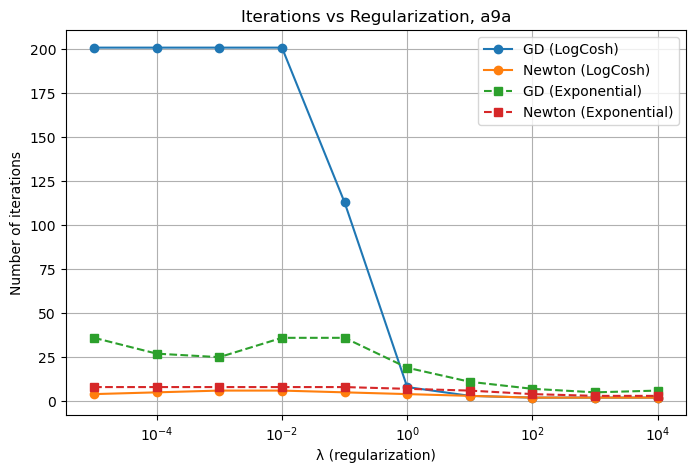

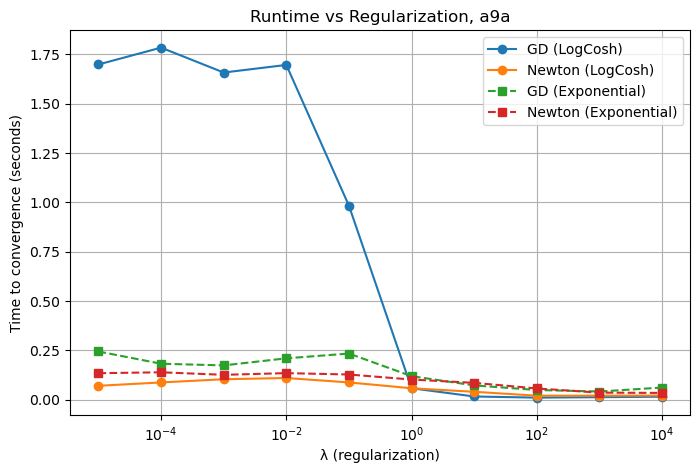

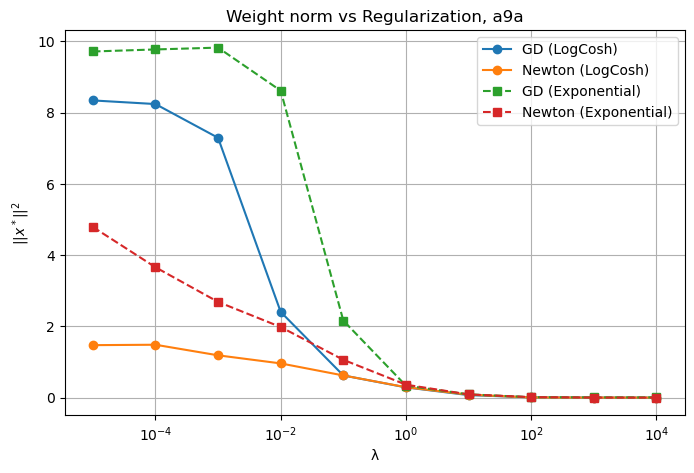

In [42]:
X, y = load_svmlight_file(os.path.join(DATA_FOLDER, DATASETS['a9a']))
test_data_set(X, y, 'a9a', gd_max_iter=200, new_max_iter=20, gd_eps=5e-6, new_eps=5e-6)